# IY021 – SimCLR Embeddings + SVM: Dual-Channel (mCherry + GFP) Experimental Data

**Goal:** Classify cells by **TF × glucose condition** (6 classes: Nrg1/Rtg1 × 2%/0.1%/0.01% glucose) using frozen SimCLR backbones applied to both channels independently. mCherry and GFP embeddings are concatenated before the SVM.

Chance level = 1/6 ≈ 16.7%.

**Data:** `EXP-25-IY008/4_transformed_exp_time_series/`

In [22]:
import re
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXP_DIR = Path("/home/ianyang/stochastic_simulations/experiments")
META_COLS = ["id", "group", "experiment"]

RANDOM_STATE = 42
IY021_DIR = EXP_DIR / "EXP-26-IY021"
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Device: {DEVICE}")

Device: cuda


## 1. Load Experimental Data & Assign Labels

In [23]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}
print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [24]:
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
META_COLS = ["id", "group", "experiment"]

# Each entry: (mCherry_stem, GFP_stem, label, glucose_pct, TF)
# Label = TF × glucose condition (6 classes)
# Exclusions: 19554 (Mig1/unknown TFs), 19566/group_1344 (ambiguous TF), Cat8 (only 2 of 3 conditions)
FILE_PAIRS = [
    # Nrg1 strain (group 1346)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series",
     0, "2%",    "Nrg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series",
     1, "0.1%",  "Nrg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series",
     2, "0.01%", "Nrg1"),
    # Rtg1 strain (group 1347)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series",
     3, "2%",    "Rtg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series",
     4, "0.1%",  "Rtg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series",
     5, "0.01%", "Rtg1"),
]

label_names = {
    0: "Nrg1 @ 2% glc",    1: "Nrg1 @ 0.1% glc",  2: "Nrg1 @ 0.01% glc",
    3: "Rtg1 @ 2% glc",    4: "Rtg1 @ 0.1% glc",  5: "Rtg1 @ 0.01% glc",
}

# ── Load & merge channels per cell ──────────────────────────────────────────
all_m, all_g, all_y, all_strain = [], [], [], []

for mc_stem, gfp_stem, label, glc, tf in FILE_PAIRS:
    df_m = pd.read_csv(DATA_DIR / f"{mc_stem}.csv")
    df_g = pd.read_csv(DATA_DIR / f"{gfp_stem}.csv")

    tc_m = [c for c in df_m.columns if c not in META_COLS]
    tc_g = [c for c in df_g.columns if c not in META_COLS]

    # Keep only cells present in both channels
    common = set(df_m["id"]) & set(df_g["id"])
    df_m = df_m[df_m["id"].isin(common)].set_index("id").sort_index()
    df_g = df_g[df_g["id"].isin(common)].set_index("id").sort_index()

    all_m.append(df_m[tc_m].values.astype(float))
    all_g.append(df_g[tc_g].values.astype(float))
    all_y.extend([label] * len(common))
    all_strain.extend([tf] * len(common))
    print(f"  {tf} (GFP) / Msn2 (mCherry) @ {glc:>5s} glc  "
          f"— {len(common)} paired cells  "
          f"[mCherry: {len(tc_m)} tp, GFP: {len(tc_g)} tp]")

# Truncate each channel to its own global minimum across all files
min_tp_m = min(a.shape[1] for a in all_m)
min_tp_g = min(a.shape[1] for a in all_g)
print(f"\nTruncating: mCherry → {min_tp_m} tp, GFP → {min_tp_g} tp")

all_m = [a[:, :min_tp_m] for a in all_m]
all_g = [a[:, :min_tp_g] for a in all_g]

# Concatenate channels: [mCherry | GFP]
X_m   = np.vstack(all_m)   # (N, min_tp_m)  — kept separate for plotting
X_g   = np.vstack(all_g)   # (N, min_tp_g)
X_raw = np.concatenate([X_m, X_g], axis=1)   # (N, min_tp_m + min_tp_g)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} combined timepoints "
      f"({min_tp_m} mCherry + {min_tp_g} GFP)")
for lbl, name in label_names.items():
    print(f"  {lbl}: {name:22s} → {np.sum(y == lbl):4d} cells")

  Nrg1 (GFP) / Msn2 (mCherry) @    2% glc  — 84 paired cells  [mCherry: 128 tp, GFP: 232 tp]
  Nrg1 (GFP) / Msn2 (mCherry) @  0.1% glc  — 231 paired cells  [mCherry: 135 tp, GFP: 219 tp]
  Nrg1 (GFP) / Msn2 (mCherry) @ 0.01% glc  — 231 paired cells  [mCherry: 105 tp, GFP: 104 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @    2% glc  — 78 paired cells  [mCherry: 126 tp, GFP: 146 tp]


  Rtg1 (GFP) / Msn2 (mCherry) @  0.1% glc  — 200 paired cells  [mCherry: 117 tp, GFP: 80 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @ 0.01% glc  — 275 paired cells  [mCherry: 89 tp, GFP: 165 tp]

Truncating: mCherry → 89 tp, GFP → 80 tp
Dataset: 1099 cells × 169 combined timepoints (89 mCherry + 80 GFP)
  0: Nrg1 @ 2% glc          →   84 cells
  1: Nrg1 @ 0.1% glc        →  231 cells
  2: Nrg1 @ 0.01% glc       →  231 cells
  3: Rtg1 @ 2% glc          →   78 cells
  4: Rtg1 @ 0.1% glc        →  200 cells
  5: Rtg1 @ 0.01% glc       →  275 cells


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_dual_channel_trace_overview.png


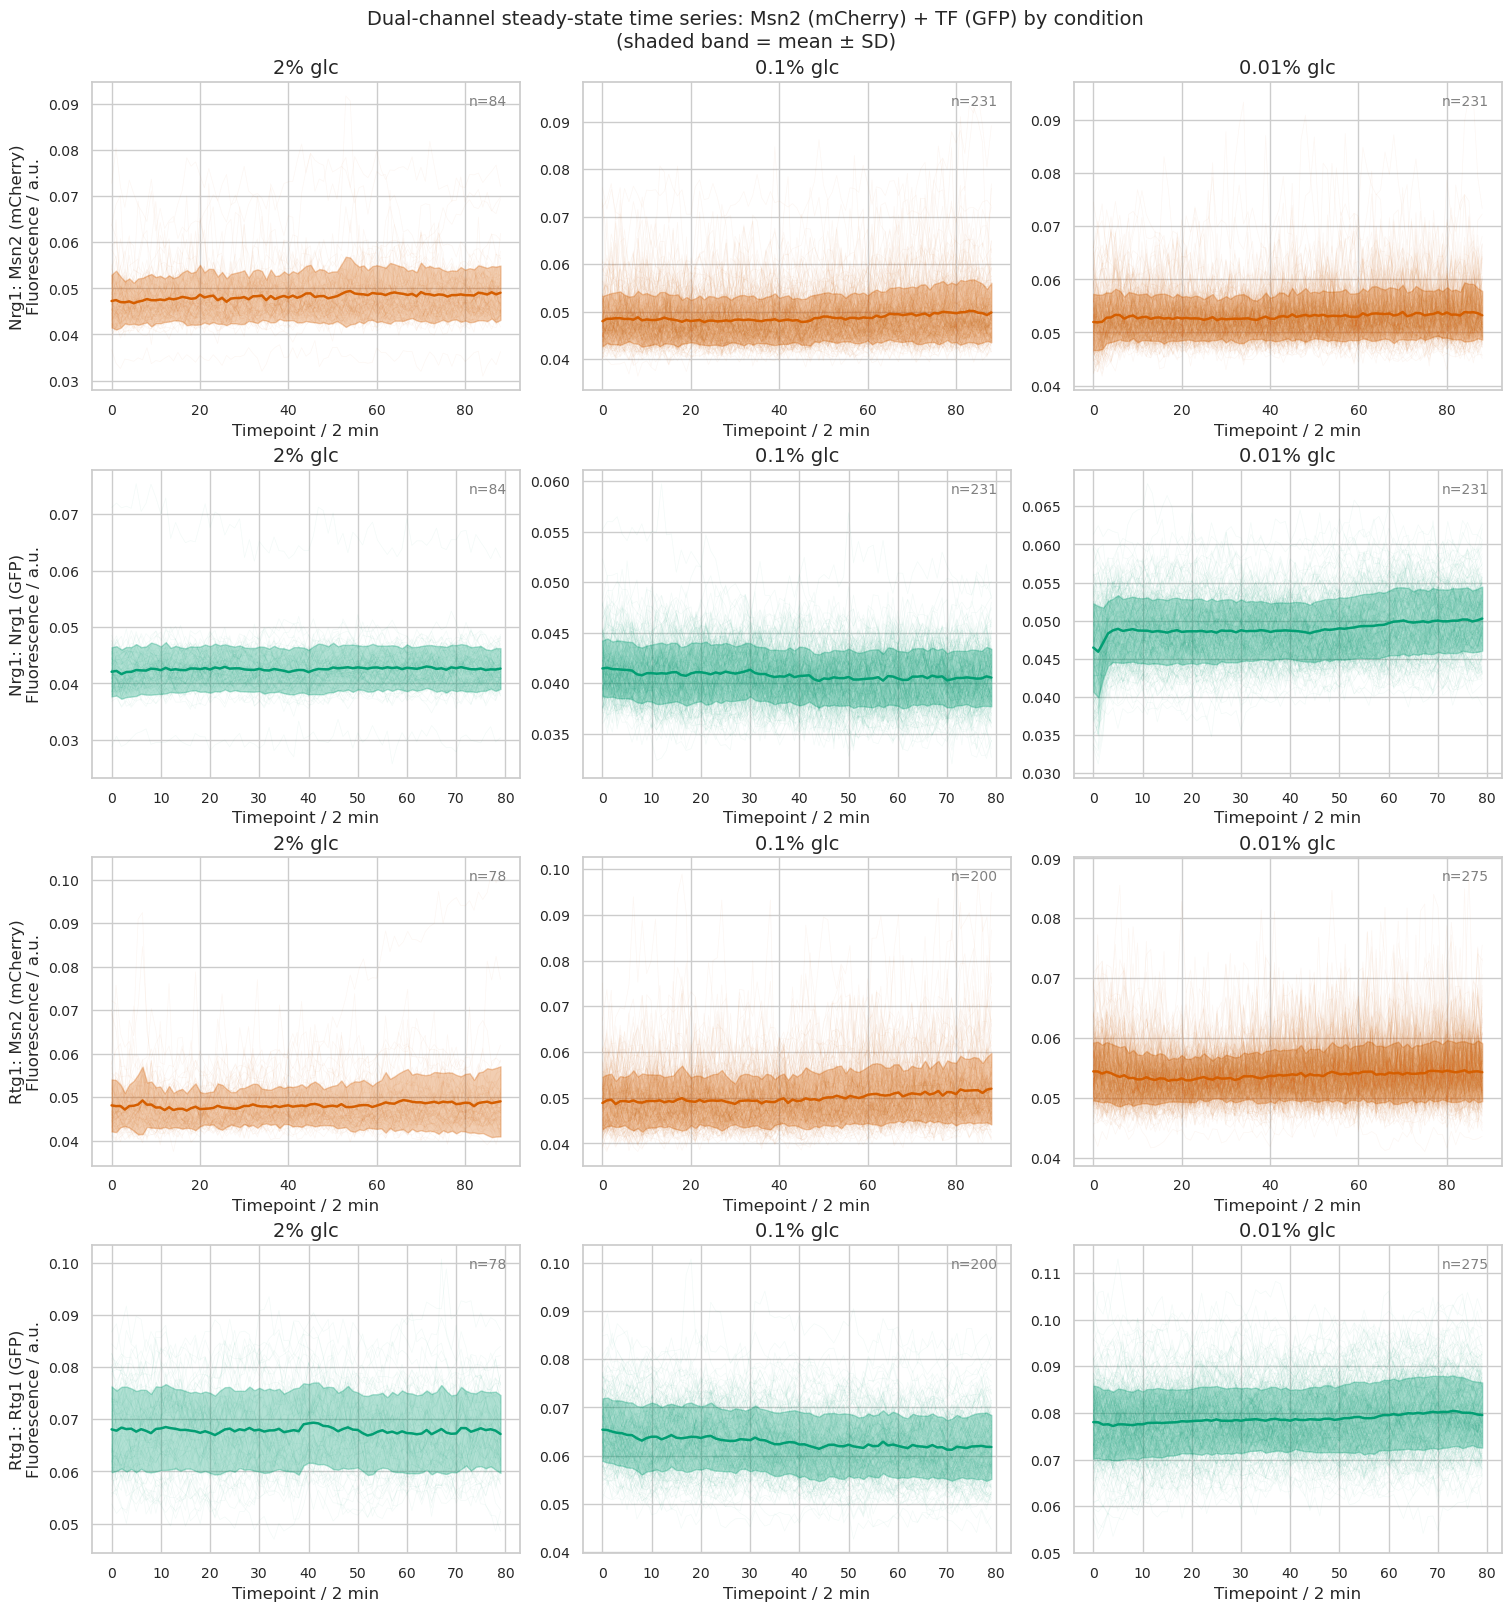

In [25]:
palette    = sns.color_palette("colorblind")
mc_color   = palette[3]  # reddish — mCherry
gfp_color  = palette[2]  # green   — GFP

tfs        = ["Nrg1", "Rtg1"]
glc_labels = ["2% glc", "0.1% glc", "0.01% glc"]
t_m = np.arange(min_tp_m)
t_g = np.arange(min_tp_g)

# Rows: Nrg1-mCherry, Nrg1-GFP, Rtg1-mCherry, Rtg1-GFP
row_info = [
    ("Nrg1", "mCherry", "Msn2 (mCherry)", mc_color,  [0, 1, 2], t_m, X_m),
    ("Nrg1", "GFP",     "Nrg1 (GFP)",    gfp_color, [0, 1, 2], t_g, X_g),
    ("Rtg1", "mCherry", "Msn2 (mCherry)", mc_color,  [3, 4, 5], t_m, X_m),
    ("Rtg1", "GFP",     "Rtg1 (GFP)",    gfp_color, [3, 4, 5], t_g, X_g),
]
n_rows, n_cols = len(row_info), len(glc_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                         sharey=False, sharex=False, constrained_layout=True)

for row, (tf, ch, ch_label, color, labels, t_ax, X_ch) in enumerate(row_info):
    for col, (lbl, glc) in enumerate(zip(labels, glc_labels)):
        ax    = axes[row, col]
        mask  = y == lbl
        X_sub = X_ch[mask]

        for trace in X_sub:
            ax.plot(t_ax, trace, color=color, alpha=0.05, linewidth=0.5)
        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            sd   = np.nanstd(X_sub, axis=0)
            ax.plot(t_ax, mean, color=color, linewidth=1.8)
            ax.fill_between(t_ax, mean - sd, mean + sd, color=color, alpha=0.3)

        ax.set_title(glc, fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf}: {ch_label}\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=10, color="gray")

fig.suptitle(
    "Dual-channel steady-state time series: Msn2 (mCherry) + TF (GFP) by condition\n"
    "(shaded band = mean ± SD)",
    fontsize=14,
)
fig_path = IY021_DIR / "IY021_dual_channel_trace_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 2. Preprocessing: NaN Fill, Balance & Normalise

In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from utils.processing.imputation import fill_nans

# Fill NaNs in each channel separately, then recombine
X_m_clean = fill_nans(X_m)
X_g_clean = fill_nans(X_g)
X_clean   = np.concatenate([X_m_clean, X_g_clean], axis=1)
print(f"NaN remaining: {np.isnan(X_clean).sum()}")

# Balance to minority class
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Balancing to {min_count} samples per class")

rng = np.random.default_rng(42)
bal_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])

X_m_bal = X_m_clean[bal_idx]
X_g_bal = X_g_clean[bal_idx]
y_bal   = y[bal_idx]

# Split first, then normalise each channel independently using train stats
splits = train_test_split(X_m_bal, X_g_bal, y_bal,
                          test_size=0.2, random_state=42, stratify=y_bal)
X_m_train, X_m_test, X_g_train, X_g_test, y_train, y_test = splits

scaler_m = StandardScaler()
X_m_train = scaler_m.fit_transform(X_m_train)
X_m_test  = scaler_m.transform(X_m_test)
scaler_g = StandardScaler()
X_g_train = scaler_g.fit_transform(X_g_train)
X_g_test  = scaler_g.transform(X_g_test)

print(f"Balanced: {len(y_bal)} cells  |  class counts: {np.bincount(y_bal)}")
print(f"Train {len(y_train)}  |  Test {len(y_test)}")
print("Normalisation: batch-wise z-score fit on train per channel, applied to test")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_dual_simclr_balanced_class_traces.png


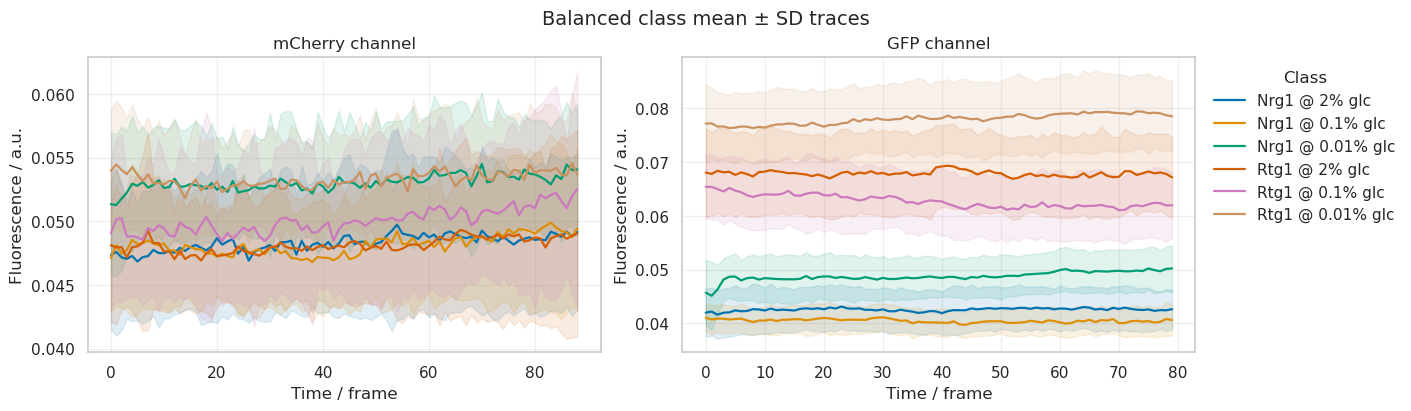

In [27]:
class_names_bal = [label_names[i] for i in sorted(label_names)]
palette = sns.color_palette("colorblind", n_colors=len(class_names_bal))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=False, sharey=False, constrained_layout=True)

for lbl, class_name in enumerate(class_names_bal):
    mask = y_bal == lbl
    color = palette[lbl]
    for ax_i, (X_ch, n_tp) in enumerate([(X_m_bal, min_tp_m), (X_g_bal, min_tp_g)]):
        mean = X_ch[mask].mean(axis=0)
        sd = X_ch[mask].std(axis=0, ddof=1)
        axes[ax_i].plot(np.arange(n_tp), mean, label=class_name, color=color, linewidth=1.6)
        axes[ax_i].fill_between(np.arange(n_tp), mean - sd, mean + sd, color=color, alpha=0.12)

axes[0].set_title("mCherry channel")
axes[1].set_title("GFP channel")
for ax in axes:
    ax.set_xlabel("Time / frame")
    ax.set_ylabel("Fluorescence / a.u.")
    ax.grid(alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="Class")
fig.suptitle("Balanced class mean ± SD traces", fontsize=14)
fig_path = IY021_DIR / "IY021_dual_simclr_balanced_class_traces.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()


## 3. SimCLR Model Registry & Dual-Channel Encoding

Each channel (mCherry, GFP) is encoded separately by the frozen backbone, then the two embedding vectors are concatenated before the SVM.

In [ ]:
from utils.embeddings import make_checkpoint_short_label, make_unique_checkpoint_label
from utils.embeddings import parse_arch_from_name, load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_checkpoint_short_label(p, NORM_OVERRIDES),
            "label": make_unique_checkpoint_label(p, len(MODEL_REGISTRY), NORM_OVERRIDES),
            "experiment": d,
        })

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch_from_name(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")

# ── Dual-channel encoding: encode each channel separately, concatenate ───────
def run_simclr_svm_dual(model, Xm_tr, Xm_te, Xg_tr, Xg_te, y_tr, y_te, device):
    """Encode mCherry and GFP separately, concatenate embeddings, then fit an RBF SVM."""
    Zm_tr = encode_channel(model, Xm_tr, device)
    Zm_te = encode_channel(model, Xm_te, device)
    Zg_tr = encode_channel(model, Xg_tr, device)
    Zg_te = encode_channel(model, Xg_te, device)
    Z_tr  = np.concatenate([Zm_tr, Zg_tr], axis=1)
    Z_te  = np.concatenate([Zm_te, Zg_te], axis=1)
    scaler   = StandardScaler()
    Z_tr_sc  = scaler.fit_transform(Z_tr)
    Z_te_sc  = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

## 4. Run All Models

In [29]:
result_rows = []
predictions = {}  # {str(ckpt_path): y_pred}

for row in MODEL_REGISTRY:
    ckpt_path = row["path"]
    label = row["label"]
    print(f"\n{'=' * 70}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")
    try:
        model = load_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm_dual(
            model, X_m_train, X_m_test, X_g_train, X_g_test, y_train, y_test, DEVICE)
        predictions[str(ckpt_path)] = y_pred
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": acc,
            "status": "ok",
            "error": "",
        })
        print(f"  Accuracy: {acc:.4f}")
    except Exception as exc:
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": np.nan,
            "status": "failed",
            "error": str(exc),
        })
        print(f"  FAILED: {exc}")

results_df = pd.DataFrame(result_rows).sort_values("accuracy", ascending=False, na_position="last").reset_index(drop=True)
results_path = IY021_DIR / "IY021_dual_channel_simclr_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved: {results_path}")
display(results_df.head(12))


Model: IY017-inst b100 D128 #00
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth
  Accuracy: 0.6596

Model: IY017-inst b100 D128 #01
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth
  Accuracy: 0.6915

Model: IY017-inst b1024 D16 164413
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth
  Accuracy: 0.7447

Model: IY017-inst b1024 D16 061239
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_061239_model.pth
  Accuracy: 0.7660

Model: IY017-inst b128 D16 151037
  IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth
  Accuracy: 0.7553

Model: IY017-inst b16 D16 #05
  IY017_simCLR_b16_lr0.01_L2_H4_D16_model.pth
  Accuracy: 0.7021

Model: IY017-inst b16 D16 #06
  IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.6383

Model: IY017-inst b2048 D16 162432
  IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth
  Accuracy: 0.7128

Model: IY017-inst b256 D16 154425
  IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth
  Accuracy: 0.7128

Mode

  Accuracy: 0.6915

Model: IY017-inst b4096 D16 023947
  IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260225_023947_model.pth
  Accuracy: 0.6489

Model: IY017-inst b512 D16 154043
  IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_154043_model.pth
  Accuracy: 0.7872

Model: IY017-inst b64 D16 163742
  IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163742_model.pth
  Accuracy: 0.7340

Model: IY017-inst b64 D16 100838
  IY017_simCLR_b64_lr0.01_L2_H4_D16_20260216_100838_model.pth
  Accuracy: 0.6915

Model: IY017-inst b64 D16 215100
  IY017_simCLR_b64_lr0.01_L2_H4_D16_20260223_215100_model.pth
  Accuracy: 0.6383

Model: IY017-inst b64 D8 092414
  IY017_simCLR_b64_lr0.01_L2_H4_D8_20260224_092414_model.pth
  Accuracy: 0.6170

Model: IY017-inst b64 D16 #17
  IY017_simCLR_b64_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.5638

Model: IY022-global b64 D16 170229
  IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model.pth
  Accuracy: 0.6702

Model: IY022-global b64 D16 125632
  IY022_simCLR_b64_lr0.01_L2_H4_

,label,short_label,experiment,checkpoint,checkpoint_name,accuracy,status,error
0,IY024-batch b64 D16 122627,IY024-batch b64 D16,EXP-26-IY024,/home/ianyang/stochastic_simulations/experimen...,IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4...,0.787234,ok,
1,IY017-inst b512 D16 154043,IY017-inst b512 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_15...,0.787234,ok,
2,IY023-batch b64 D16 104312,IY023-batch b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_batch-...,0.776596,ok,
3,IY024-batch b64 D16 210002,IY024-batch b64 D16,EXP-26-IY024,/home/ianyang/stochastic_simulations/experimen...,IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4...,0.765957,ok,
4,IY023-batch b64 D8 120151,IY023-batch b64 D8,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D8_batch-w...,0.765957,ok,
5,IY017-inst b1024 D16 061239,IY017-inst b1024 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_0...,0.765957,ok,
6,IY017-inst b128 D16 151037,IY017-inst b128 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_15...,0.755319,ok,
7,IY017-inst b1024 D16 164413,IY017-inst b1024 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_1...,0.744681,ok,
8,IY023-joint b64 D16 165118,IY023-joint b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165...,0.744681,ok,
9,IY017-inst b64 D16 163742,IY017-inst b64 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163...,0.734043,ok,


## 5. Results Visualisation

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_dual_channel_simclr_results.png


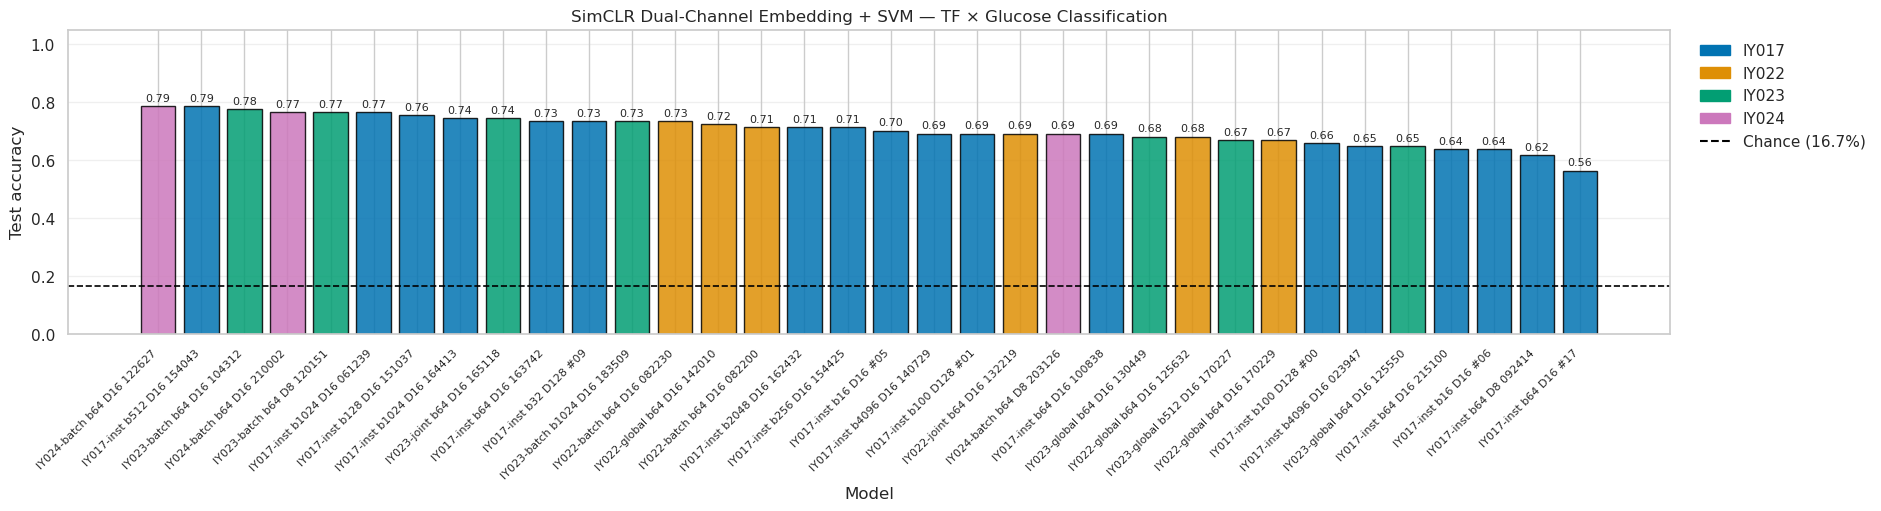

Best model: IY024-batch b64 D16 122627 (0.7872)
Checkpoint: IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth
Chance: 0.1667


In [30]:
valid_results = results_df[results_df["status"] == "ok"].copy()
class_names = [label_names[i] for i in sorted(label_names)]
chance = 1 / len(label_names)
palette = sns.color_palette("colorblind")

color_map = {
    "EXP-26-IY017": palette[0],
    "EXP-26-IY022": palette[1],
    "EXP-26-IY023": palette[2],
    "EXP-26-IY024": palette[4],
}
bar_colors = [color_map.get(exp, palette[7]) for exp in valid_results["experiment"]]

fig, ax = plt.subplots(figsize=(max(14, len(valid_results) * 0.55), 5), constrained_layout=True)
bars = ax.bar(range(len(valid_results)), valid_results["accuracy"], color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
ax.set_xticks(range(len(valid_results)))
ax.set_xticklabels(valid_results["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Test accuracy")
ax.set_title("SimCLR Dual-Channel Embedding + SVM — TF × Glucose Classification")
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, valid_results["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

legend_handles = [
    Patch(color=palette[0], label="IY017"),
    Patch(color=palette[1], label="IY022"),
    Patch(color=palette[2], label="IY023"),
    Patch(color=palette[4], label="IY024"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"Chance ({chance:.1%})"),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

fig_path = IY021_DIR / "IY021_dual_channel_simclr_results.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

best = valid_results.iloc[0]
print(f"Best model: {best['label']} ({best['accuracy']:.4f})")
print(f"Checkpoint: {best['checkpoint_name']}")
print(f"Chance: {chance:.4f}")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_dual_channel_simclr_top_confusion_matrices.png


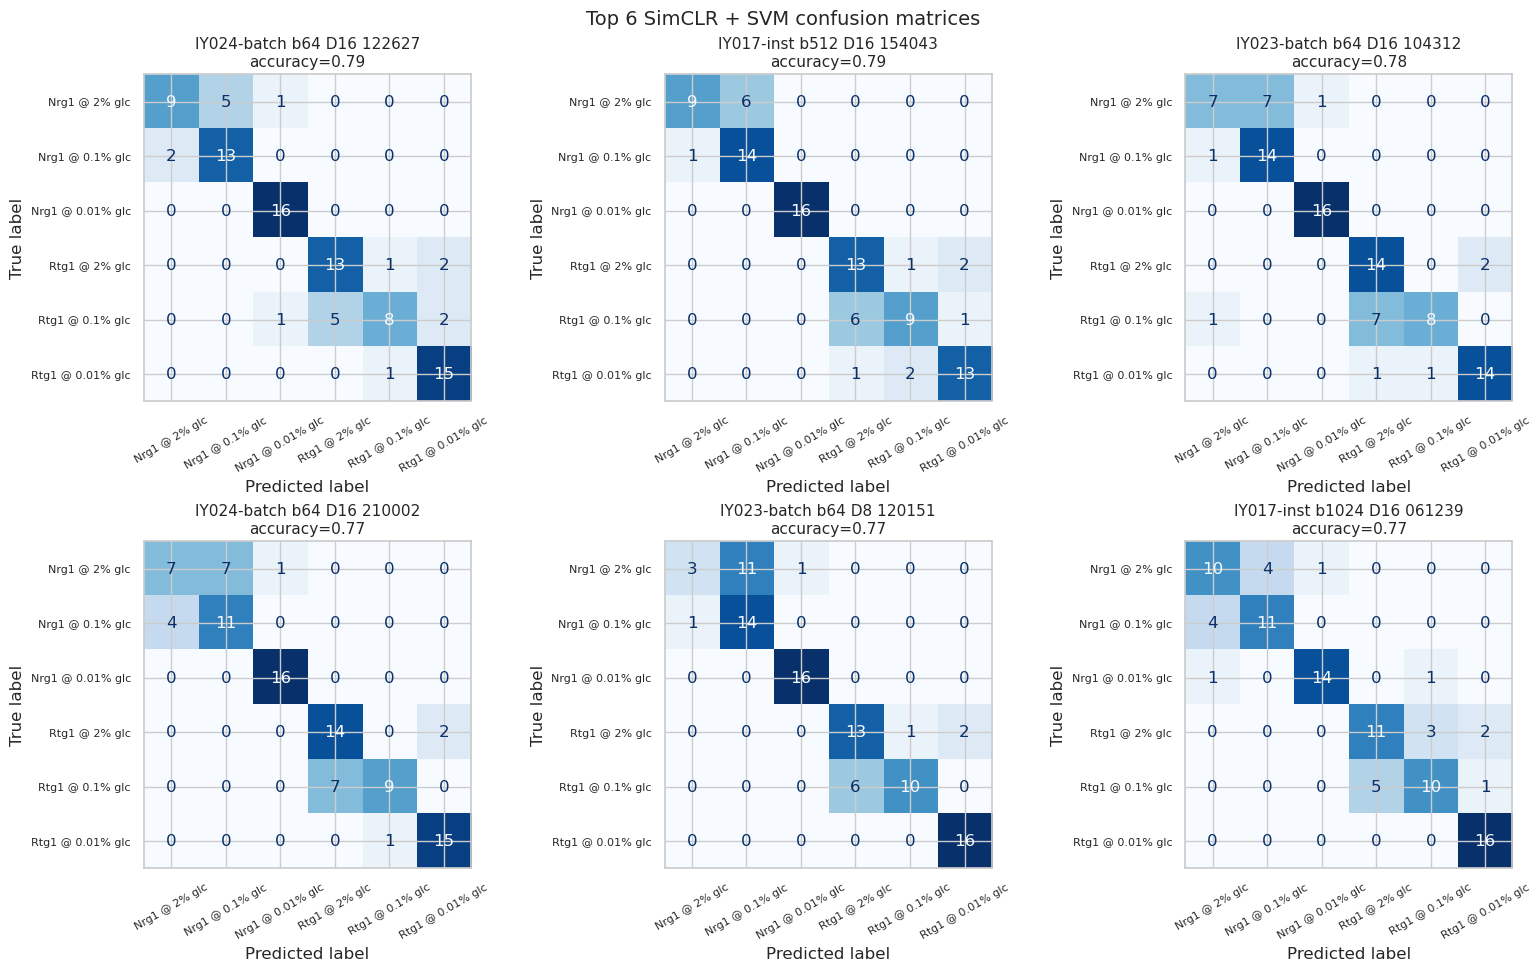

In [31]:
TOP_N_CONFUSION = 6
top_results = valid_results.head(TOP_N_CONFUSION)
ncols = min(3, len(top_results))
nrows = int(np.ceil(len(top_results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, (_, row) in zip(axes, top_results.iterrows()):
    y_pred = predictions[row["checkpoint"]]
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap="Blues",
        xticks_rotation=30,
    )
    ax.set_title(f"{row['label']}\naccuracy={row['accuracy']:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

for ax in axes[len(top_results):]:
    ax.axis("off")

fig.suptitle(f"Top {len(top_results)} SimCLR + SVM confusion matrices", fontsize=14)
conf_path = IY021_DIR / "IY021_dual_channel_simclr_top_confusion_matrices.png"
fig.savefig(conf_path, dpi=300, bbox_inches="tight")
print(f"Saved: {conf_path}")
plt.show()

In [32]:
best_checkpoint = valid_results.iloc[0]["checkpoint"]
best_pred = predictions[best_checkpoint]
print(classification_report(y_test, best_pred, target_names=class_names))

                  precision    recall  f1-score   support

   Nrg1 @ 2% glc       0.82      0.60      0.69        15
 Nrg1 @ 0.1% glc       0.72      0.87      0.79        15
Nrg1 @ 0.01% glc       0.89      1.00      0.94        16
   Rtg1 @ 2% glc       0.72      0.81      0.76        16
 Rtg1 @ 0.1% glc       0.80      0.50      0.62        16
Rtg1 @ 0.01% glc       0.79      0.94      0.86        16

        accuracy                           0.79        94
       macro avg       0.79      0.79      0.78        94
    weighted avg       0.79      0.79      0.78        94

